In [ ]:
import pandas as pd
import duckdb
import plotly.express as px
import sys
from pathlib import Path

BASE_DIR = Path.cwd().parent
if str(BASE_DIR) not in sys.path:
    sys.path.append(str(BASE_DIR))

from src.utils.data_loader import load_datasets
from src.services.bcb_api import fetch_exchange_rates

dfs = load_datasets(["vendas_2023_2024.csv"], layer="raw")
dfs.update(load_datasets(["produtos_processed.csv", "custos_importacao_processed.csv"]))

df_sales = dfs["vendas_2023_2024.csv"]
df_products = dfs["produtos_processed.csv"]
df_costs = dfs["custos_importacao_processed.csv"]

df_sales["sale_date"] = pd.to_datetime(df_sales["sale_date"], format="mixed", dayfirst=True).dt.date
df_costs["start_date"] = pd.to_datetime(df_costs["start_date"], format="mixed", dayfirst=True).dt.date

df_rates = fetch_exchange_rates("01-01-2022", "12-31-2024")

if df_rates.empty:
    raise ValueError("ERRO CRÍTICO: df_rates está vazio. A API do Banco Central falhou.")

df_rates["rate_date"] = pd.to_datetime(df_rates["rate_date"]).dt.date
df_rates["usd_rate"] = df_rates["usd_rate"].astype(str).str.replace(',', '.').astype(float)

In [ ]:
query_elite_clients = """
WITH base_data AS (
    SELECT
        v.id_client,
        v.id as sell_id,
        v.total,
        v.qtd,
        p.actual_category
    FROM df_sales v
    INNER JOIN df_products p 
        ON v.id_product = p.code
),
customer_metrics AS (
    SELECT
        id_client,
        SUM(total) AS total_revenue,
        COUNT(DISTINCT sell_id) AS frequency,
        SUM(total) / NULLIF(COUNT(DISTINCT sell_id), 0) AS average_ticket,
        COUNT(DISTINCT actual_category) AS category_diversity
    FROM base_data
    GROUP BY id_client
),
top_10_elite AS (
    SELECT 
        id_client,
        average_ticket,
        category_diversity
    FROM customer_metrics
    WHERE category_diversity >= 3
    ORDER BY 
        average_ticket DESC, 
        id_client ASC
    LIMIT 10
),
elite_purchases AS (
    SELECT
        b.actual_category,
        SUM(b.qtd) AS total_items_sold
    FROM base_data b
    INNER JOIN top_10_elite t 
        ON b.id_client = t.id_client
    GROUP BY b.actual_category
)
SELECT 
    actual_category, 
    total_items_sold
FROM elite_purchases
ORDER BY total_items_sold DESC;
"""

df_elite_category_ranking = duckdb.query(query_elite_clients).df()

if not df_elite_category_ranking.empty:
    top_category = df_elite_category_ranking.iloc[0]

    print("======================== INSIGHTS ===========================")
    print("Considerando APENAS os Top 10 Clientes Fiéis (Ticket Médio Alto + 3 ou mais categorias):")
    print(f"A categoria mais vendida foi: {top_category['actual_category'].upper()}")
    print(f"Total absoluto: {int(top_category['total_items_sold'])} itens comprados.")
    print("===========================================================\n")

    print(df_elite_category_ranking.to_string(index=False))
else:
    print("Nenhum cliente atendeu aos critérios de Elite definidos.")

=== BLUF (Bottom Line Up Front) - RESPOSTA EXECUTIVA ===
O cliente com o MAIOR lucro acumulado histórico é o: Cliente 42
Lucro Absoluto Gerado: R$ 688,857,644.20



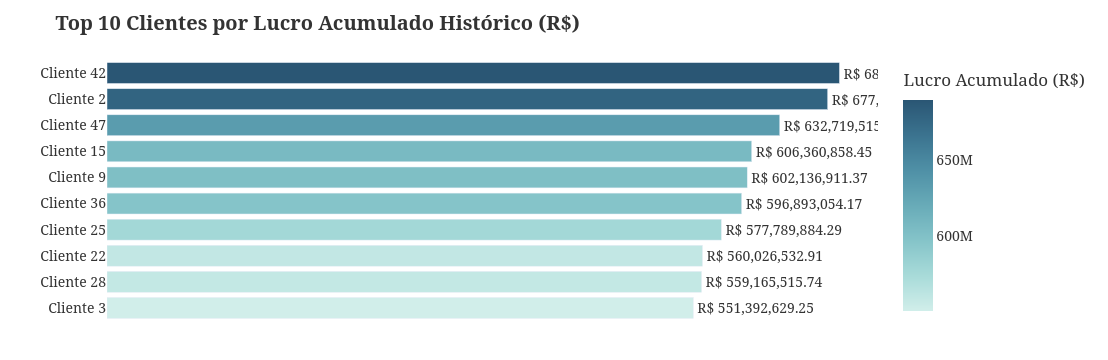

In [3]:
query_customer_profit = """
WITH sales_costs AS (
    SELECT
        s.id_client,
        s.id AS sell_id,
        s.sale_date,
        s.total AS unit_price, -- Renomeado para refletir a realidade dos dados
        s.qtd,
        c.usd_price
    FROM df_sales s
    LEFT JOIN df_costs c
        ON s.id_product = c.product_id 
       AND s.sale_date >= c.start_date
    QUALIFY ROW_NUMBER() OVER (PARTITION BY s.id ORDER BY c.start_date DESC) = 1
),
financials AS (
    SELECT
        sc.id_client,
        sc.sell_id,
        (sc.unit_price * sc.qtd) AS total_revenue_brl,
        (sc.usd_price * fx.usd_rate * sc.qtd) AS total_cost_brl,
        (sc.unit_price * sc.qtd) - (sc.usd_price * fx.usd_rate * sc.qtd) AS profit_margin
    FROM sales_costs sc
    LEFT JOIN df_rates fx
        ON sc.sale_date >= fx.rate_date
    QUALIFY ROW_NUMBER() OVER (PARTITION BY sc.sell_id ORDER BY fx.rate_date DESC) = 1
)
SELECT
    'Cliente ' || CAST(id_client AS VARCHAR) AS client_name,
    SUM(COALESCE(profit_margin, 0)) AS total_profit
FROM financials
GROUP BY id_client
HAVING SUM(COALESCE(profit_margin, 0)) > 0
ORDER BY total_profit DESC
LIMIT 10;
"""

df_top_customers = duckdb.query(query_customer_profit).df()

if df_top_customers.empty:
    print("⚠️ ALERTA: A query não encontrou nenhum cliente com lucro positivo.")
else:
    top_client = df_top_customers.iloc[0]

    print("=== BLUF (Bottom Line Up Front) - RESPOSTA EXECUTIVA ===")
    print(f"O cliente com o MAIOR lucro acumulado histórico é o: {top_client['client_name']}")
    print(f"Lucro Absoluto Gerado: R$ {top_client['total_profit']:,.2f}")
    print("========================================================\n")

    # Gráfico Plotly com layout executivo
    fig = px.bar(
        df_top_customers.sort_values(by="total_profit", ascending=True),
        x="total_profit",
        y="client_name",
        orientation="h",
        title="<b>Top 10 Clientes por Lucro Acumulado Histórico (R$)</b>",
        labels={
            "total_profit": "Lucro Acumulado (R$)",
            "client_name": "Identificação do Cliente"
        },
        text="total_profit",
        color="total_profit",
        color_continuous_scale="Teal"
    )

    fig.update_layout(
        plot_bgcolor="white",
        font=dict(family="Arial", size=14, color="#333333"),
        showlegend=False,
        margin=dict(l=20, r=60, t=60, b=20)
    )

    fig.update_traces(
        texttemplate="R$ %{text:,.2f}",
        textposition="outside",
        hovertemplate="<b>%{y}</b><br>Lucro: R$ %{x:,.2f}<extra></extra>"
    )

    fig.update_xaxes(showgrid=False, showticklabels=False, title="")
    fig.update_yaxes(title="")

    fig.show()

=== RISCO DE CONCENTRAÇÃO ===
O faturamento total vem de uma base de 49 clientes.
No entanto, 80% de toda a receita da empresa está concentrada em apenas 36 clientes (73.5% da base).
SAÚDE DA BASE: A receita está bem distribuída e não sofre do risco severo de Pareto.



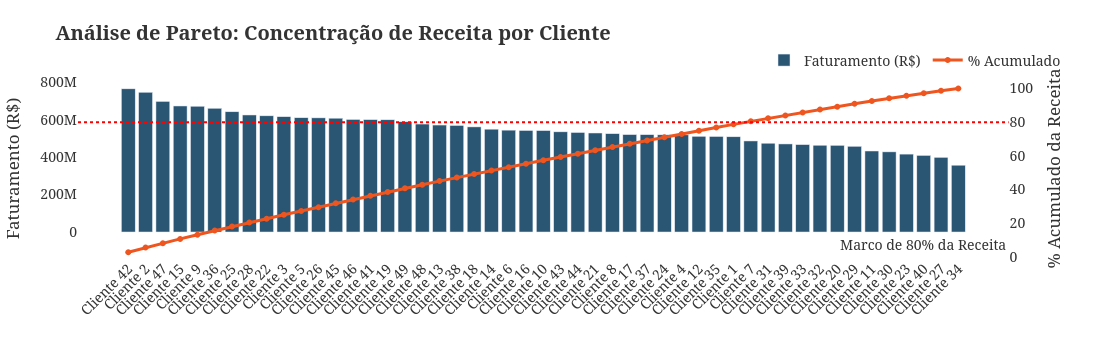

In [7]:
from plotly.subplots import make_subplots
import plotly.graph_objects as go

query_pareto = """
WITH client_revenue AS (
    SELECT
        id_client,
        SUM(total * qtd) AS total_revenue
    FROM df_sales
    GROUP BY id_client
),
ranked_revenue AS (
    SELECT
        'Cliente ' || CAST(id_client AS VARCHAR) AS client_name,
        total_revenue,
        SUM(total_revenue) OVER (ORDER BY total_revenue DESC ROWS BETWEEN UNBOUNDED PRECEDING AND CURRENT ROW) AS cumulative_revenue,
        SUM(total_revenue) OVER () AS grand_total
    FROM client_revenue
)
SELECT
    client_name,
    total_revenue,
    (cumulative_revenue / grand_total) * 100 AS cumulative_percentage
FROM ranked_revenue
ORDER BY total_revenue DESC;
"""

df_pareto = duckdb.query(query_pareto).df()

# Summary
total_clientes = len(df_pareto)

clientes_80_porcento = len(df_pareto[df_pareto['cumulative_percentage'] <= 80])
concentracao = (clientes_80_porcento / total_clientes) * 100

print("=== RISCO DE CONCENTRAÇÃO ===")
print(f"O faturamento total vem de uma base de {total_clientes} clientes.")
print(f"No entanto, 80% de toda a receita da empresa está concentrada em apenas {clientes_80_porcento} clientes ({concentracao:.1f}% da base).")
if concentracao <= 20:
    print("ALERTA DE RISCO ALTO: A regra de Pareto (80/20) é muito forte aqui. A perda de um top cliente causará grande impacto.")
else:
    print("SAÚDE DA BASE: A receita está bem distribuída e não sofre do risco severo de Pareto.")
print("===========================================================\n")

fig = make_subplots(specs=[[{"secondary_y": True}]])

fig.add_trace(
    go.Bar(
        x=df_pareto['client_name'],
        y=df_pareto['total_revenue'],
        name="Faturamento (R$)",
        marker_color='rgb(42, 86, 116)',
        hovertemplate="Faturamento: R$ %{y:,.2f}<extra></extra>"
    ),
    secondary_y=False,
)

fig.add_trace(
    go.Scatter(
        x=df_pareto['client_name'],
        y=df_pareto['cumulative_percentage'],
        name="% Acumulado",
        mode='lines+markers',
        line=dict(color='rgb(239, 85, 30)', width=3),
        marker=dict(size=6),
        hovertemplate="Acumulado: %{y:.1f}%<extra></extra>"
    ),
    secondary_y=True,
)

fig.update_layout(
    title="<b>Análise de Pareto: Concentração de Receita por Cliente</b>",
    plot_bgcolor="white",
    font=dict(family="Arial", size=14, color="#333333"),
    hovermode="x unified", # Mostra as informações de ambas as linhas num mesmo balão ao passar o mouse
    legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="right", x=1),
    margin=dict(l=40, r=40, t=80, b=40)
)

fig.update_xaxes(title_text="", showgrid=False, tickangle=-45)
fig.update_yaxes(title_text="Faturamento (R$)", showgrid=False, secondary_y=False)
fig.update_yaxes(title_text="% Acumulado da Receita", range=[0, 105], showgrid=False, secondary_y=True)

fig.add_hline(y=80, line_dash="dot", line_color="red", secondary_y=True, 
              annotation_text="Marco de 80% da Receita", annotation_position="bottom right")

fig.show()